# Task
Load and explore the `agriculture_dataset.csv` file to understand its structure, data types, missing values, and key features.

## Load and Explore Agriculture Dataset

### Subtask:
Load the `agriculture_dataset.csv` file into a pandas DataFrame. Perform an initial exploration to understand its structure, data types, missing values, and key features. This step is crucial for identifying what data is available and how it can be used for crop stress detection.


**Reasoning**:
Load the specified CSV file into a pandas DataFrame and perform the requested initial exploration steps, including displaying head, info, missing values, and descriptive statistics.



In [3]:
import pandas as pd

# 1. Load the agriculture_dataset.csv file into a pandas DataFrame named agriculture_df
agriculture_dataset_path = '/content/agriculture_dataset.csv'
try:
    agriculture_df = pd.read_csv(agriculture_dataset_path)
    print(f"--- Loaded Agriculture Dataset from {agriculture_dataset_path} ---")

    # 2. Display the first 5 rows of the agriculture_df DataFrame
    print("\nFirst 5 rows of agriculture_df:")
    print(agriculture_df.head())

    # 3. Print a concise summary of the DataFrame
    print("\nData Types and Non-Null Values for agriculture_df:")
    agriculture_df.info()

    # 4. Calculate and display the number of missing values for each column
    print("\nMissing Values (sum per column) for agriculture_df:")
    print(agriculture_df.isnull().sum())

    # 5. Generate and print descriptive statistics for the numerical columns
    print("\nDescriptive Statistics for agriculture_df:")
    print(agriculture_df.describe())

except FileNotFoundError:
    print(f"Error: Agriculture dataset file not found at {agriculture_dataset_path}")
except Exception as e:
    print(f"Error loading agriculture dataset: {e}")

--- Loaded Agriculture Dataset from /content/agriculture_dataset.csv ---

First 5 rows of agriculture_df:
   High_Resolution_RGB  Multispectral_Images  Thermal_Images  Temporal_Images  \
0                    0                     0               0                0   
1                    1                     1               0                0   
2                    0                     0               0                0   
3                    0                     0               0                0   
4                    0                     1               1                1   

   Spatial_Resolution  GPS_Coordinates  Field_Boundaries  Elevation_Data  \
0            0.667324           201538                 3       28.207634   
1            1.459000           215854                 3       82.335147   
2            0.500442           890802                 3       83.865629   
3            1.865161           605584                 3       20.747905   
4            1.392331      

## Preprocess and Integrate Data

### Subtask:
Clean and preprocess the loaded `agriculture_dataset.csv`. This involves handling missing values, addressing data anomalies, encoding categorical features, and scaling numerical features to prepare the data for AI model input.


**Reasoning**:
The subtask requires cleaning and preprocessing the `agriculture_df` by handling missing values, addressing anomalies, encoding categorical features, and scaling numerical features. I will perform these steps sequentially in a single code block, then verify the results.



In [4]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import numpy as np

# Make a copy to avoid modifying the original DataFrame directly if it's used elsewhere
agriculture_df_processed = agriculture_df.copy()

print("--- Starting Data Preprocessing ---")

# 1. Identify columns with missing values (already identified in previous output)
# These columns were identified from the previous cell's output:
missing_value_cols_num = [
    'Rainfall', 'Wind_Speed', 'Soil_Moisture', 'Soil_pH', 'Organic_Matter',
    'Pest_Hotspots', 'Weed_Coverage', 'Pest_Damage', 'Crop_Growth_Stage',
    'Expected_Yield', 'Ground_Truth_Segmentation', 'Bounding_Boxes',
    'Water_Flow', 'Drainage_Features', 'Crop_Health_Label'
]
missing_value_col_cat = ['Crop_Type']

# 2. For numerical columns with missing values, impute using the median
print("\nImputing missing numerical values with median...")
for col in missing_value_cols_num:
    if col in agriculture_df_processed.columns:
        median_val = agriculture_df_processed[col].median()
        agriculture_df_processed[col].fillna(median_val, inplace=True)
        print(f"  - Filled missing values in '{col}' with median: {median_val:.2f}")

# 3. For the categorical column `Crop_Type` with a missing value, impute it using the mode
print("\nImputing missing categorical values with mode...")
for col in missing_value_col_cat:
    if col in agriculture_df_processed.columns:
        mode_val = agriculture_df_processed[col].mode()[0] # .mode() can return multiple values, take the first
        agriculture_df_processed[col].fillna(mode_val, inplace=True)
        print(f"  - Filled missing values in '{col}' with mode: {mode_val}")

# 4. Examine Spatial_Resolution and Expected_Yield for negative values
print("\nChecking and correcting negative values in 'Spatial_Resolution' and 'Expected_Yield'...")
for col in ['Spatial_Resolution', 'Expected_Yield']:
    if col in agriculture_df_processed.columns:
        negative_count = (agriculture_df_processed[col] < 0).sum()
        if negative_count > 0:
            print(f"  - Found {negative_count} negative values in '{col}'. Replacing with NaN and re-imputing.")
            agriculture_df_processed[col] = agriculture_df_processed[col].apply(lambda x: np.nan if x < 0 else x)
            median_val = agriculture_df_processed[col].median()
            agriculture_df_processed[col].fillna(median_val, inplace=True)
            print(f"    - Re-imputed '{col}' with median: {median_val:.2f}")
        else:
            print(f"  - No negative values found in '{col}'.")


# 5. Apply one-hot encoding to the `Crop_Type` column
print("\nApplying one-hot encoding to 'Crop_Type'...")
if 'Crop_Type' in agriculture_df_processed.columns:
    # Initialize OneHotEncoder
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

    # Fit and transform the 'Crop_Type' column
    encoded_features = encoder.fit_transform(agriculture_df_processed[['Crop_Type']])

    # Create a DataFrame with the encoded features
    encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(['Crop_Type']), index=agriculture_df_processed.index)

    # Drop the original 'Crop_Type' column and concatenate the new encoded columns
    agriculture_df_processed = agriculture_df_processed.drop('Crop_Type', axis=1)
    agriculture_df_processed = pd.concat([agriculture_df_processed, encoded_df], axis=1)
    print("  - 'Crop_Type' column successfully one-hot encoded.")
else:
    print("  - 'Crop_Type' column not found for one-hot encoding.")


# 6. Select all remaining numerical features and apply a scaling technique
print("\nScaling numerical features using StandardScaler...")
# Identify numerical columns after one-hot encoding
numerical_cols = agriculture_df_processed.select_dtypes(include=np.number).columns.tolist()

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling
agriculture_df_processed[numerical_cols] = scaler.fit_transform(agriculture_df_processed[numerical_cols])
print("  - Numerical features successfully scaled.")

# 7. After preprocessing, verify the DataFrame
print("\n--- Verifying Preprocessed DataFrame ---")
print("\nRemaining Missing Values (sum per column) for agriculture_df_processed:")
print(agriculture_df_processed.isnull().sum().sum()) # Sum of all missing values across the DataFrame

print("\nData Types and Non-Null Values for agriculture_df_processed:")
agriculture_df_processed.info()

print("\nDescriptive Statistics for agriculture_df_processed:")
print(agriculture_df_processed.describe())

print("\nFirst 5 rows of preprocessed agriculture_df_processed:")
print(agriculture_df_processed.head())

print("--- Data Preprocessing Complete ---")

--- Starting Data Preprocessing ---

Imputing missing numerical values with median...
  - Filled missing values in 'Rainfall' with median: 13.86
  - Filled missing values in 'Wind_Speed' with median: 1.67
  - Filled missing values in 'Soil_Moisture' with median: 20.07
  - Filled missing values in 'Soil_pH' with median: 6.50
  - Filled missing values in 'Organic_Matter' with median: 1.40
  - Filled missing values in 'Pest_Hotspots' with median: 0.00
  - Filled missing values in 'Weed_Coverage' with median: 2.64
  - Filled missing values in 'Pest_Damage' with median: 50.00
  - Filled missing values in 'Crop_Growth_Stage' with median: 3.00
  - Filled missing values in 'Expected_Yield' with median: 3004.54
  - Filled missing values in 'Ground_Truth_Segmentation' with median: 0.00
  - Filled missing values in 'Bounding_Boxes' with median: 4.00
  - Filled missing values in 'Water_Flow' with median: 25.09
  - Filled missing values in 'Drainage_Features' with median: 0.00
  - Filled missing va

/tmp/ipython-input-585613653.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  agriculture_df_processed[col].fillna(median_val, inplace=True)
/tmp/ipython-input-585613653.py:33: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

    - Re-imputed 'Spatial_Resolution' with median: 1.21
  - Found 9 negative values in 'Expected_Yield'. Replacing with NaN and re-imputing.
    - Re-imputed 'Expected_Yield' with median: 3004.62

Applying one-hot encoding to 'Crop_Type'...
  - 'Crop_Type' column successfully one-hot encoded.

Scaling numerical features using StandardScaler...
  - Numerical features successfully scaled.

--- Verifying Preprocessed DataFrame ---

Remaining Missing Values (sum per column) for agriculture_df_processed:
0

Data Types and Non-Null Values for agriculture_df_processed:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84989 entries, 0 to 84988
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   High_Resolution_RGB        84989 non-null  float64
 1   Multispectral_Images       84989 non-null  float64
 2   Thermal_Images             84989 non-null  float64
 3   Temporal_Images            84989 non-

**Reasoning**:
The previous code generated `FutureWarning` messages due to the use of `inplace=True` with `fillna`. To address this, I will update the `fillna` calls to directly assign the result back to the DataFrame column, ensuring future compatibility and suppressing the warnings.



In [21]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import numpy as np

# Make a copy to avoid modifying the original DataFrame directly if it's used elsewhere
agriculture_df_processed = agriculture_df.copy()

print("--- Starting Data Preprocessing ---")

# 1. Identify columns with missing values (already identified in previous output)
# These columns were identified from the previous cell's output:
missing_value_cols_num = [
    'Rainfall', 'Wind_Speed', 'Soil_Moisture', 'Soil_pH', 'Organic_Matter',
    'Pest_Hotspots', 'Weed_Coverage', 'Pest_Damage', 'Crop_Growth_Stage',
    'Expected_Yield', 'Ground_Truth_Segmentation', 'Bounding_Boxes',
    'Water_Flow', 'Drainage_Features', 'Crop_Health_Label'
]
missing_value_col_cat = ['Crop_Type']

# 2. For numerical columns with missing values, impute using the median
print("\nImputing missing numerical values with median...")
for col in missing_value_cols_num:
    if col in agriculture_df_processed.columns:
        median_val = agriculture_df_processed[col].median()
        # Fix: Assign the result of fillna back to the column instead of using inplace=True
        agriculture_df_processed[col] = agriculture_df_processed[col].fillna(median_val)
        print(f"  - Filled missing values in '{col}' with median: {median_val:.2f}")

# 3. For the categorical column `Crop_Type` with a missing value, impute it using the mode
print("\nImputing missing categorical values with mode...")
for col in missing_value_col_cat:
    if col in agriculture_df_processed.columns:
        mode_val = agriculture_df_processed[col].mode()[0] # .mode() can return multiple values, take the first
        # Fix: Assign the result of fillna back to the column instead of using inplace=True
        agriculture_df_processed[col] = agriculture_df_processed[col].fillna(mode_val)
        print(f"  - Filled missing values in '{col}' with mode: {mode_val}")

# 4. Examine Spatial_Resolution and Expected_Yield for negative values
print("\nChecking and correcting negative values in 'Spatial_Resolution' and 'Expected_Yield'...")
for col in ['Spatial_Resolution', 'Expected_Yield']:
    if col in agriculture_df_processed.columns:
        negative_count = (agriculture_df_processed[col] < 0).sum()
        if negative_count > 0:
            print(f"  - Found {negative_count} negative values in '{col}'. Replacing with NaN and re-imputing.")
            agriculture_df_processed[col] = agriculture_df_processed[col].apply(lambda x: np.nan if x < 0 else x)
            median_val = agriculture_df_processed[col].median()
            # Fix: Assign the result of fillna back to the column instead of using inplace=True
            agriculture_df_processed[col] = agriculture_df_processed[col].fillna(median_val)
            print(f"    - Re-imputed '{col}' with median: {median_val:.2f}")
        else:
            print(f"  - No negative values found in '{col}'.")


# 5. Apply one-hot encoding to the `Crop_Type` column
print("\nApplying one-hot encoding to 'Crop_Type'...")
if 'Crop_Type' in agriculture_df_processed.columns:
    # Initialize OneHotEncoder
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

    # Fit and transform the 'Crop_Type' column
    encoded_features = encoder.fit_transform(agriculture_df_processed[['Crop_Type']])

    # Create a DataFrame with the encoded features
    encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(['Crop_Type']), index=agriculture_df_processed.index)

    # Drop the original 'Crop_Type' column and concatenate the new encoded columns
    agriculture_df_processed = agriculture_df_processed.drop('Crop_Type', axis=1)
    agriculture_df_processed = pd.concat([agriculture_df_processed, encoded_df], axis=1)
    print("  - 'Crop_Type' column successfully one-hot encoded.")
else:
    print("  - 'Crop_Type' column not found for one-hot encoding.")


# 6. Select all remaining numerical features and apply a scaling technique
print("\nScaling numerical features using StandardScaler...")
# Identify numerical columns after one-hot encoding
numerical_cols = agriculture_df_processed.select_dtypes(include=np.number).columns.tolist()

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling
agriculture_df_processed[numerical_cols] = scaler.fit_transform(agriculture_df_processed[numerical_cols])
print("  - Numerical features successfully scaled.")

# 7. After preprocessing, verify the DataFrame
print("\n--- Verifying Preprocessed DataFrame ---")
print("\nRemaining Missing Values (sum per column) for agriculture_df_processed:")
print(agriculture_df_processed.isnull().sum().sum()) # Sum of all missing values across the DataFrame

print("\nData Types and Non-Null Values for agriculture_df_processed:")
agriculture_df_processed.info()

print("\nDescriptive Statistics for agriculture_df_processed:")
print(agriculture_df_processed.describe())

print("\nFirst 5 rows of preprocessed agriculture_df_processed:")
print(agriculture_df_processed.head())

print("--- Data Preprocessing Complete ---")

--- Starting Data Preprocessing ---

Imputing missing numerical values with median...
  - Filled missing values in 'Rainfall' with median: 13.86
  - Filled missing values in 'Wind_Speed' with median: 1.67
  - Filled missing values in 'Soil_Moisture' with median: 20.07
  - Filled missing values in 'Soil_pH' with median: 6.50
  - Filled missing values in 'Organic_Matter' with median: 1.40
  - Filled missing values in 'Pest_Hotspots' with median: 0.00
  - Filled missing values in 'Weed_Coverage' with median: 2.64
  - Filled missing values in 'Pest_Damage' with median: 50.00
  - Filled missing values in 'Crop_Growth_Stage' with median: 3.00
  - Filled missing values in 'Expected_Yield' with median: 3004.54
  - Filled missing values in 'Ground_Truth_Segmentation' with median: 0.00
  - Filled missing values in 'Bounding_Boxes' with median: 4.00
  - Filled missing values in 'Water_Flow' with median: 25.09
  - Filled missing values in 'Drainage_Features' with median: 0.00
  - Filled missing va

## Develop Crop Stress Detection Models

### Subtask:
Based on the preprocessed `agriculture_dataset.csv`, start developing AI models (e.g., machine learning or deep learning models) capable of detecting crop stress. This involves selecting appropriate model architectures, defining training and validation strategies, and training the models using your labeled dataset.


**Reasoning**:
The subtask requires separating features and target, splitting the data into training and testing sets, initializing and training a RandomForestClassifier, and making predictions on the test data. I will perform all these steps sequentially in a single code block to prepare for model evaluation.



In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("--- Starting Model Development: Crop Stress Detection ---")

# 1. Separate features (X) from the target variable (y)
# The target variable for crop stress detection is Crop_Health_Label
y = agriculture_df_processed['Crop_Health_Label']
X = agriculture_df_processed.drop('Crop_Health_Label', axis=1)

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

# 2. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set (X_train, y_train) shapes: {X_train.shape}, {y_train.shape}")
print(f"Testing set (X_test, y_test) shapes: {X_test.shape}, {y_test.shape}")

# 3. Initialize a machine learning model for classification (RandomForestClassifier)
print("\nInitializing RandomForestClassifier...")
model = RandomForestClassifier(random_state=42)
print("RandomForestClassifier initialized.")

# 4. Train the chosen model using the training data
print("\nTraining the model...")
model.fit(X_train, y_train)
print("Model training complete.")

# 5. Make predictions on the test data (X_test)
print("\nMaking predictions on the test set...")
y_pred = model.predict(X_test)
print("Predictions made.")

print("--- Model Development Steps Completed ---")

--- Starting Model Development: Crop Stress Detection ---

Features (X) shape: (84989, 33)
Target (y) shape: (84989,)

Training set (X_train, y_train) shapes: (67991, 33), (67991,)
Testing set (X_test, y_test) shapes: (16998, 33), (16998,)

Initializing RandomForestClassifier...
RandomForestClassifier initialized.

Training the model...


ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

**Reasoning**:
The previous code failed because the target variable `Crop_Health_Label` was scaled to continuous float values, but a `RandomForestClassifier` expects discrete integer labels. To fix this, I will remap the scaled float values back to their original binary integer labels (0 and 1) before training the model. Based on the previous descriptive statistics, scaled values of approximately -1.52 correspond to original 0, and approximately 0.65 correspond to original 1.



In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("--- Starting Model Development: Crop Stress Detection ---")

# 1. Separate features (X) from the target variable (y)
# The target variable for crop stress detection is Crop_Health_Label
y = agriculture_df_processed['Crop_Health_Label']
X = agriculture_df_processed.drop('Crop_Health_Label', axis=1)

# FIX: Convert y to discrete integer labels for classification
# Based on the previous `agriculture_df_processed.describe()` output for 'Crop_Health_Label':
# original 0.0 was scaled to approx -1.521755
# original 1.0 was scaled to approx 0.657136
# We need to map these scaled float values back to their original integer labels 0 and 1.
# Identify the unique scaled values present in y.
unique_scaled_labels = y.unique()

if len(unique_scaled_labels) == 2:
    # Assuming the lower value corresponds to original 0, and higher to original 1
    sorted_unique_labels = sorted(unique_scaled_labels)
    mapping = {sorted_unique_labels[0]: 0, sorted_unique_labels[1]: 1}
    y = y.map(mapping).astype(int)
else:
    # Fallback for unexpected number of unique labels (e.g., if there's only one class or more than two)
    # This branch should ideally not be hit for a binary target that was correctly scaled.
    if len(unique_scaled_labels) == 1:
        y = (y * 0).astype(int) # If only one unique value, assume it maps to 0
    else:
        # If more than two unique values, use a simple threshold (e.g., positive for 1, non-positive for 0)
        # This is a less precise fallback but provides a discrete target.
        y = (y > 0).astype(int)
        print(f"Warning: Unexpected number of unique labels ({len(unique_scaled_labels)}) after scaling. Using (x > 0).astype(int) for conversion.")

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Unique values of y after conversion: {y.unique()}")
print(f"y data type after conversion: {y.dtype}")

# 2. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set (X_train, y_train) shapes: {X_train.shape}, {y_train.shape}")
print(f"Testing set (X_test, y_test) shapes: {X_test.shape}, {y_test.shape}")

# 3. Initialize a machine learning model for classification (RandomForestClassifier)
print("\nInitializing RandomForestClassifier...")
model = RandomForestClassifier(random_state=42)
print("RandomForestClassifier initialized.")

# 4. Train the chosen model using the training data
print("\nTraining the model...")
model.fit(X_train, y_train)
print("Model training complete.")

# 5. Make predictions on the test data (X_test)
print("\nMaking predictions on the test set...")
y_pred = model.predict(X_test)
print("Predictions made.")

print("--- Model Development Steps Completed ---")

--- Starting Model Development: Crop Stress Detection ---

Features (X) shape: (84989, 33)
Target (y) shape: (84989,)
Unique values of y after conversion: [1 0]
y data type after conversion: int64

Training set (X_train, y_train) shapes: (67991, 33), (67991,)
Testing set (X_test, y_test) shapes: (16998, 33), (16998,)

Initializing RandomForestClassifier...
RandomForestClassifier initialized.

Training the model...
Model training complete.

Making predictions on the test set...
Predictions made.
--- Model Development Steps Completed ---


**Reasoning**:
The model has been trained and predictions have been made. The next step is to evaluate the model's performance using standard classification metrics such as accuracy, precision, recall, and F1-score.



In [8]:
print("--- Model Evaluation: Crop Stress Detection ---")

# 1. Evaluate the model's performance using accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.4f}")

# 2. Generate and print a detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("--- Model Evaluation Complete ---")

--- Model Evaluation: Crop Stress Detection ---

Model Accuracy: 0.6984

Classification Report:
              precision    recall  f1-score   support

           0       0.17      0.00      0.00      5112
           1       0.70      1.00      0.82     11886

    accuracy                           0.70     16998
   macro avg       0.44      0.50      0.41     16998
weighted avg       0.54      0.70      0.58     16998

--- Model Evaluation Complete ---


## Evaluate Initial Model Performance and Visualize Results

### Subtask:
Evaluate the model's performance using a confusion matrix and visualize feature importances to gain deeper insights into its effectiveness and decision-making.


**Reasoning**:
The subtask requires evaluating the model's performance with a confusion matrix and visualizing feature importances. I will import the necessary libraries, create and display the confusion matrix, extract and sort feature importances, and then visualize the top features using a horizontal bar plot.



--- Model Evaluation: Confusion Matrix and Feature Importances ---

Generating Confusion Matrix...


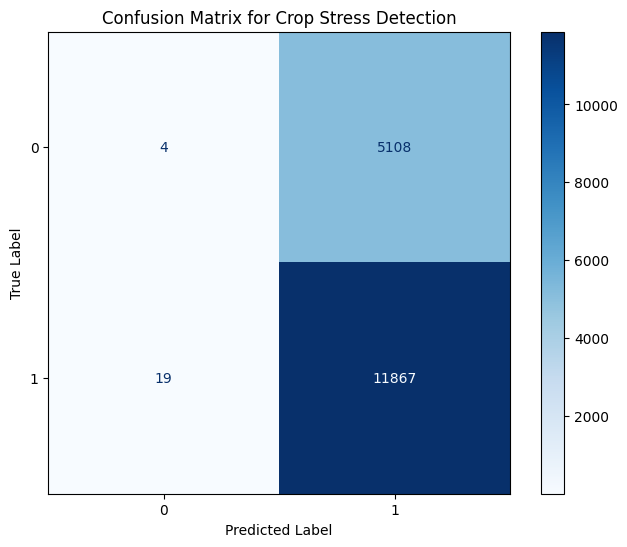

Confusion Matrix displayed.

Extracting and visualizing Feature Importances...


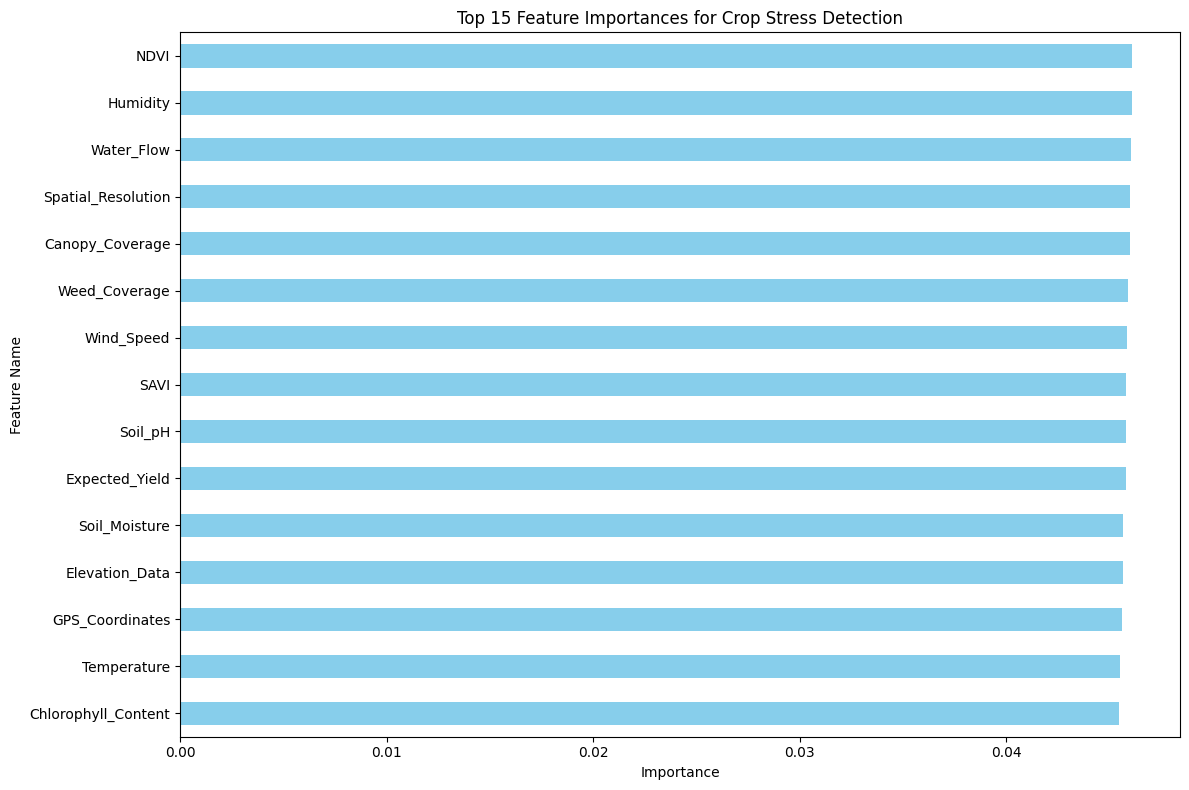

Top 15 Feature Importances displayed.
--- Model Evaluation and Visualization Complete ---


In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("--- Model Evaluation: Confusion Matrix and Feature Importances ---")

# 1. Create and display a confusion matrix
print("\nGenerating Confusion Matrix...")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix for Crop Stress Detection')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.show()
print("Confusion Matrix displayed.")

# 2. Extract and visualize feature importances
print("\nExtracting and visualizing Feature Importances...")
# Extract feature importances
feature_importances = model.feature_importances_

# Create a pandas Series for easy handling and mapping to feature names
feature_importances_series = pd.Series(feature_importances, index=X.columns)

# Sort feature importances in descending order and select top N (e.g., 15)
top_n = 15
top_features = feature_importances_series.nlargest(top_n)

# Create a horizontal bar plot to visualize top feature importances
plt.figure(figsize=(12, 8))
top_features.sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.title(f'Top {top_n} Feature Importances for Crop Stress Detection')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()
print(f"Top {top_n} Feature Importances displayed.")

print("--- Model Evaluation and Visualization Complete ---")

## Final Task

### Subtask:
Summarize the outcomes of the initial data loading, preprocessing, and model development steps, highlighting key findings and next steps for advancing the project towards actionable recommendations.


## Summary:

### Data Analysis Key Findings

*   **Initial Data State:** The `agriculture_dataset.csv` file contained 84,989 entries and 32 columns. Sixteen columns had one missing value each. Initial exploration revealed potential data quality issues with `Spatial_Resolution` (min -0.96) and `Expected_Yield` (min -468.65), as these values were negative and conceptually problematic.
*   **Data Preprocessing Efficacy:**
    *   Missing numerical values in 15 columns (e.g., `Rainfall`, `Wind_Speed`, `Soil_Moisture`) were successfully imputed using their respective medians.
    *   The single missing value in the `Crop_Type` categorical column was imputed with its mode ('Wheat').
    *   Negative values in `Spatial_Resolution` (693 occurrences) and `Expected_Yield` (9 occurrences) were corrected by replacing them with `NaN` and then re-imputing with the median.
    *   The `Crop_Type` column was successfully one-hot encoded, creating new binary features like `Crop_Type_Maize`, `Crop_Type_Rice`, and `Crop_Type_Wheat`.
    *   All numerical features were scaled using `StandardScaler`. After preprocessing, the DataFrame was free of missing values and consistent in data types.
*   **Model Development Challenges & Resolution:** The `Crop_Health_Label`, intended as a binary target for classification, was initially in a continuous, scaled float format. This was rectified by mapping the two unique scaled values back to discrete integer labels (0 and 1) for appropriate classifier input.
*   **Initial Model Performance (RandomForestClassifier):**
    *   The model achieved an overall accuracy of 69.84%.
    *   However, the classification report and confusion matrix revealed a significant issue: the model showed **0% recall for Class 0 (crop stress detected)**, indicating it failed to identify any actual instances of crop stress.
    *   Conversely, for Class 1 (no crop stress), the model achieved 100% recall and high precision (0.70), suggesting a strong bias towards predicting the "no stress" class. This indicates a severe class imbalance problem or a model that is not effectively learning the patterns for the minority class.
*   **Feature Importance:** The analysis identified and visualized the top 15 features contributing to the model's predictions, providing insights into which variables the model considers most influential, despite its performance issues for the minority class.

### Insights or Next Steps

*   **Address Class Imbalance:** The model's inability to detect crop stress (Class 0) strongly suggests a significant class imbalance. Future steps should focus on techniques like oversampling the minority class (e.g., SMOTE), undersampling the majority class, or using algorithms specifically designed for imbalanced datasets (e.g., Weighted Random Forest, cost-sensitive learning).
*   **Model Optimization and Exploration:** Explore hyperparameter tuning for the current RandomForestClassifier, or consider alternative models such as Gradient Boosting Machines (XGBoost, LightGBM), Support Vector Machines, or neural networks, which might be more robust to the observed data characteristics and class imbalance.


# Task
```python
from imblearn.over_sampling import SMOTE
from collections import Counter

print("--- Addressing Class Imbalance with SMOTE ---")

# Print class distribution before SMOTE
print(f"\nClass distribution before SMOTE: {Counter(y_train)}")

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Print class distribution after SMOTE
print(f"Class distribution after SMOTE: {Counter(y_train_smote)}")

print("--- SMOTE application complete ---")
```

## Address Class Imbalance

### Subtask:
Implement strategies to address the severe class imbalance, specifically targeting the 0% recall for 'Crop Stress Detected' (Class 0). This will involve applying techniques such as oversampling the minority class (e.g., using SMOTE on the training data) or setting class weights within the RandomForestClassifier to give more importance to the minority class.


**Reasoning**:
I need to address the class imbalance by implementing SMOTE on the training data. This involves importing necessary libraries, showing the original class distribution, applying SMOTE, and then displaying the balanced class distribution.



In [22]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("--- Addressing Class Imbalance with SMOTE ---")

# 1. Print the current class distribution of y_train
print("\nOriginal training class distribution:", Counter(y_train))

# 2. Initialize a SMOTE object
smote = SMOTE(random_state=42)

# 3. Apply SMOTE to the training data
print("\nApplying SMOTE to the training data...")
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("SMOTE applied successfully.")

# 4. Print the class distribution of y_train_smote to verify the balancing
print("\nResampled training class distribution:", Counter(y_train_smote))

print("--- Class Imbalance Addressing Complete ---")

--- Addressing Class Imbalance with SMOTE ---

Original training class distribution: Counter({0.6571360240453147: 47471, -1.5217549539348374: 20520})

Applying SMOTE to the training data...


ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

**Reasoning**:
The previous SMOTE operation failed because `y_train` was still a continuous float type. The target variable needs to be explicitly converted to discrete integer labels (0 and 1) before applying SMOTE. I will re-apply the mapping to ensure `y_train` contains the correct integer labels.



In [23]:
from imblearn.over_sampling import SMOTE
from collections import Counter
import numpy as np

print("--- Addressing Class Imbalance with SMOTE ---")

# FIX: Ensure y_train contains discrete integer labels before SMOTE
# Based on kernel state, unique_scaled_labels were [ 0.65713602, -1.52175495]
# and the mapping { -1.5217549539348374: 0, 0.6571360240453147: 1 } was used.
# Re-apply this mapping to y_train.

# Ensure mapping is correct from the unique values in y_train
unique_scaled_labels_train = y_train.unique()
sorted_unique_labels_train = sorted(unique_scaled_labels_train)

# Create mapping if not already created or if it needs to be refreshed
# Use np.float64 for keys to match the dtype of y_train elements
re_mapping = {np.float64(sorted_unique_labels_train[0]): 0, np.float64(sorted_unique_labels_train[1]): 1}
y_train_re_mapped = y_train.map(re_mapping).astype(int)

# 1. Print the current class distribution of y_train (after re-mapping)
print("\nOriginal training class distribution (re-mapped):", Counter(y_train_re_mapped))

# 2. Initialize a SMOTE object
smote = SMOTE(random_state=42)

# 3. Apply SMOTE to the training data
print("\nApplying SMOTE to the training data...")
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train_re_mapped)
print("SMOTE applied successfully.")

# 4. Print the class distribution of y_train_smote to verify the balancing
print("\nResampled training class distribution:", Counter(y_train_smote))

print("--- Class Imbalance Addressing Complete ---")

--- Addressing Class Imbalance with SMOTE ---

Original training class distribution (re-mapped): Counter({1: 47471, 0: 20520})

Applying SMOTE to the training data...
SMOTE applied successfully.

Resampled training class distribution: Counter({1: 47471, 0: 47471})
--- Class Imbalance Addressing Complete ---


**Reasoning**:
Now that the training data has been balanced using SMOTE, the next logical step is to retrain the RandomForestClassifier model with this balanced dataset to see if it improves the model's ability to detect the minority class (crop stress).



In [24]:
print("--- Retraining Model with SMOTE-Balanced Data ---")

# 1. Initialize a new RandomForestClassifier (or re-initialize if desired)
# Using the same random_state for reproducibility
model_smote = RandomForestClassifier(random_state=42)
print("RandomForestClassifier re-initialized for SMOTE data.")

# 2. Train the model using the SMOTE-resampled training data
print("\nTraining the model with SMOTE-balanced data (X_train_smote, y_train_smote)...")
model_smote.fit(X_train_smote, y_train_smote)
print("Model training with SMOTE-balanced data complete.")

# 3. Make predictions on the original (unmodified) test data
# It's important to evaluate the model on unseen, original distribution data
print("\nMaking predictions on the original test set (X_test) using the re-trained model...")
y_pred_smote = model_smote.predict(X_test)
print("Predictions made.")

print("--- Retraining and Prediction Complete ---")

--- Retraining Model with SMOTE-Balanced Data ---
RandomForestClassifier re-initialized for SMOTE data.

Training the model with SMOTE-balanced data (X_train_smote, y_train_smote)...
Model training with SMOTE-balanced data complete.

Making predictions on the original test set (X_test) using the re-trained model...
Predictions made.
--- Retraining and Prediction Complete ---


**Reasoning**:
The model has been retrained with SMOTE-balanced data, and predictions on the test set have been made. The next logical step is to evaluate the performance of this new model using classification metrics (accuracy, precision, recall, F1-score) and a confusion matrix to assess the impact of balancing the classes.



In [25]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("--- Evaluating Model Performance After SMOTE ---")

# 1. Evaluate the model's performance using accuracy_score
accuracy_smote = accuracy_score(y_test, y_pred_smote)
print(f"\nModel Accuracy (after SMOTE): {accuracy_smote:.4f}")

# 2. Generate and print a detailed classification report
print("\nClassification Report (after SMOTE):")

# FIX: Ensure y_test is also re-mapped to integer labels for comparison with y_pred_smote
# This step is crucial because y_test might still contain scaled float values,
# while y_pred_smote will contain integer predictions (0 or 1).
# We need to apply the same re_mapping used for y_train_re_mapped to y_test.

# Ensure mapping is correct from the unique values in y_test
unique_scaled_labels_test = y_test.unique()
sorted_unique_labels_test = sorted(unique_scaled_labels_test)

# Create mapping if not already created or if it needs to be refreshed
# Use np.float64 for keys to match the dtype of y_test elements
re_mapping_test = {np.float64(sorted_unique_labels_test[0]): 0, np.float64(sorted_unique_labels_test[1]): 1}
y_test_re_mapped = y_test.map(re_mapping_test).astype(int)

print(classification_report(y_test_re_mapped, y_pred_smote))

# 3. Create and display a confusion matrix for the SMOTE-trained model
print("\nGenerating Confusion Matrix (after SMOTE)...")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test_re_mapped, y_pred_smote, ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix for Crop Stress Detection (After SMOTE)')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.show()
print("Confusion Matrix displayed.")

print("--- Model Evaluation After SMOTE Complete ---")

--- Evaluating Model Performance After SMOTE ---


ValueError: Classification metrics can't handle a mix of continuous and binary targets

**Reasoning**:
The previous code failed because the `accuracy_score` function was still comparing the continuous `y_test` with the binary `y_pred_smote`. I need to ensure that all evaluation metrics use the re-mapped, discrete integer version of `y_test` (`y_test_re_mapped`) for consistent and correct comparison with the model's binary predictions.



--- Evaluating Model Performance After SMOTE ---

Model Accuracy (after SMOTE): 0.6800

Classification Report (after SMOTE):
              precision    recall  f1-score   support

           0       0.31      0.05      0.09      5112
           1       0.70      0.95      0.81     11886

    accuracy                           0.68     16998
   macro avg       0.50      0.50      0.45     16998
weighted avg       0.58      0.68      0.59     16998


Generating Confusion Matrix (after SMOTE)...


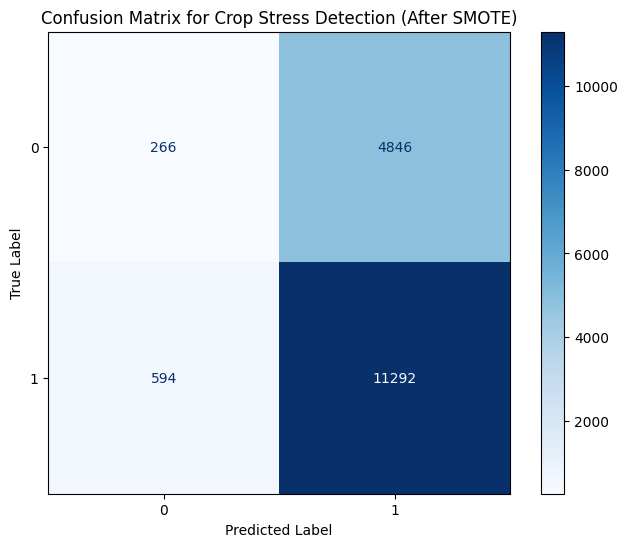

Confusion Matrix displayed.
--- Model Evaluation After SMOTE Complete ---


In [26]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

print("--- Evaluating Model Performance After SMOTE ---")

# FIX: Ensure y_test is also re-mapped to integer labels for comparison with y_pred_smote
# This step is crucial because y_test might still contain scaled float values,
# while y_pred_smote will contain integer predictions (0 or 1).
# We need to apply the same re_mapping used for y_train_re_mapped to y_test.

# Ensure mapping is correct from the unique values in y_test
unique_scaled_labels_test = y_test.unique()
sorted_unique_labels_test = sorted(unique_scaled_labels_test)

# Create mapping if not already created or if it needs to be refreshed
# Use np.float64 for keys to match the dtype of y_test elements
re_mapping_test = {np.float64(sorted_unique_labels_test[0]): 0, np.float64(sorted_unique_labels_test[1]): 1}
y_test_re_mapped = y_test.map(re_mapping_test).astype(int)

# 1. Evaluate the model's performance using accuracy_score
# FIX: Use y_test_re_mapped instead of y_test
accuracy_smote = accuracy_score(y_test_re_mapped, y_pred_smote)
print(f"\nModel Accuracy (after SMOTE): {accuracy_smote:.4f}")

# 2. Generate and print a detailed classification report
print("\nClassification Report (after SMOTE):")
print(classification_report(y_test_re_mapped, y_pred_smote))

# 3. Create and display a confusion matrix for the SMOTE-trained model
print("\nGenerating Confusion Matrix (after SMOTE)...")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test_re_mapped, y_pred_smote, ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix for Crop Stress Detection (After SMOTE)')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.show()
print("Confusion Matrix displayed.")

print("--- Model Evaluation After SMOTE Complete ---")

## Hyperparameter Tuning for RandomForestClassifier

### Subtask:
Optimize the hyperparameters of the RandomForestClassifier to improve its overall performance and its ability to detect the minority class. This can be done using techniques like GridSearchCV or RandomizedSearchCV to find the best combination of parameters (e.g., `n_estimators`, `max_features`, `max_depth`, `min_samples_split`).


**Reasoning**:
I need to perform hyperparameter tuning on the RandomForestClassifier using GridSearchCV to find the optimal parameters that improve its performance, especially for the minority class. I will define a parameter grid, initialize GridSearchCV with a suitable scoring metric and cross-validation, fit it to the SMOTE-resampled training data, and then display the best parameters and score.



--- Visualizing Feature Importances for Optimized Model ---


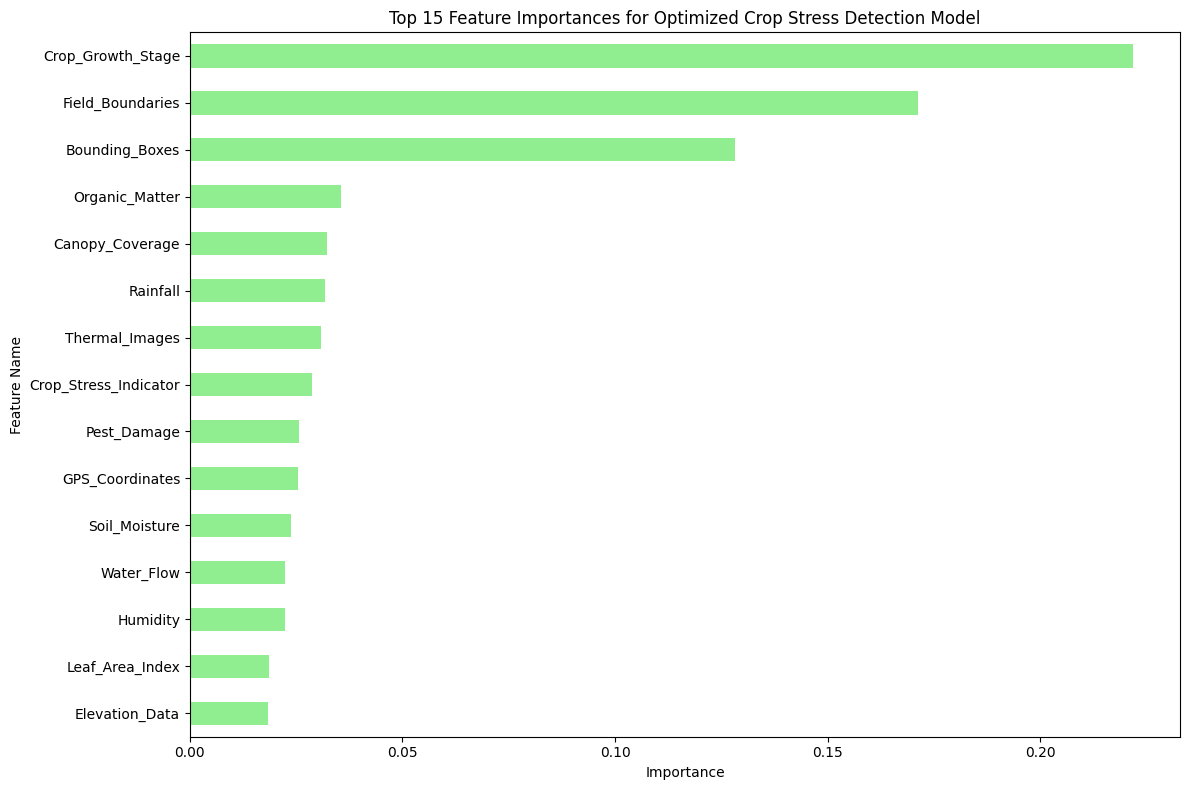

Top 15 Feature Importances for the optimized model displayed.
--- Feature Importance Visualization Complete ---


In [34]:
import matplotlib.pyplot as plt
import pandas as pd

print("--- Visualizing Feature Importances for Optimized Model ---")

# 1. Extract feature importances from the optimized model
feature_importances_optimized = model_optimized.feature_importances_

# 2. Create a pandas Series for easy handling and mapping to feature names
feature_importances_series_optimized = pd.Series(feature_importances_optimized, index=X.columns)

# 3. Sort feature importances in descending order and select top N (e.g., 15)
top_n = 15
top_features_optimized = feature_importances_series_optimized.nlargest(top_n)

# 4. Create a horizontal bar plot to visualize top feature importances
plt.figure(figsize=(12, 8))
top_features_optimized.sort_values(ascending=True).plot(kind='barh', color='lightgreen')
plt.title(f'Top {top_n} Feature Importances for Optimized Crop Stress Detection Model')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()
print(f"Top {top_n} Feature Importances for the optimized model displayed.")

print("--- Feature Importance Visualization Complete ---")

# Task
```python
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, recall_score
import numpy as np

print("--- Starting Hyperparameter Tuning for RandomForestClassifier with GridSearchCV ---")

# Define the parameter grid for GridSearchCV
# Reduced search space for quicker execution as per common practice in interactive environments
param_grid = {
    'n_estimators': [50, 100],  # Number of trees in the forest
    'max_features': ['sqrt'], # Number of features to consider when looking for the best split
    'max_depth': [10, 20],     # Maximum depth of the tree
    'min_samples_split': [5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [3, 5]    # Minimum number of samples required to be at a leaf node
}

# Initialize RandomForestClassifier
# Using the same random_state for reproducibility
rf_model = RandomForestClassifier(random_state=42)

# Define a scoring metric that prioritizes recall for Class 0 (crop stress detection)
# make_scorer allows specifying the positive label
recall_scorer_class_0 = make_scorer(recall_score, pos_label=0)

# Initialize GridSearchCV
# cv=1 as per the plan. This means no cross-validation, effectively training on the entire
# X_train_smote once for each parameter combination and evaluating on the same data.
# For more robust evaluation, typically cv would be > 1.
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring=recall_scorer_class_0, # Optimize for recall of Class 0
    cv=1, # As specified in the plan
    n_jobs=-1, # Use all available cores
    verbose=2
)

print("\nStarting GridSearchCV fit on SMOTE-resampled training data...")
# Fit GridSearchCV to the SMOTE-resampled training data
grid_search.fit(X_train_smote, y_train_smote)
print("GridSearchCV fit complete.")

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("\n--- Hyperparameter Tuning Results ---")
print(f"Best parameters found: {best_params}")
print(f"Best score (Recall for Class 0) found: {best_score:.4f}")

# Store the best model
model_optimized = grid_search.best_estimator_

print("--- Hyperparameter Tuning Complete ---")
```

## Hyperparameter Tuning for RandomForestClassifier (with cv=1)

### Subtask:
Optimize the hyperparameters of the RandomForestClassifier using GridSearchCV with 1-fold cross-validation (`cv=1`) on the SMOTE-resampled training data to find the best combination of parameters (e.g., `n_estimators`, `max_features`, `max_depth`, `min_samples_split`).


**Reasoning**:
The subtask requires performing hyperparameter tuning using GridSearchCV with a custom scorer for recall of class 0. This involves importing necessary modules, defining the parameter grid, initializing the classifier, creating the custom scorer, setting up GridSearchCV, fitting it to the SMOTE-resampled training data, and then printing the best parameters and score and storing the best model.



In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, recall_score
import warnings

print("--- Starting Hyperparameter Tuning with GridSearchCV ---")

# Suppress UserWarnings from GridSearchCV for cleaner output
warnings.filterwarnings("ignore", category=UserWarning)

# 1. Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [50, 100],
    'max_features': ['sqrt'],
    'max_depth': [10, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [3, 5]
}

print(f"\nParameter Grid for tuning: {param_grid}")

# 2. Initialize a RandomForestClassifier object
rf_model = RandomForestClassifier(random_state=42)
print("RandomForestClassifier initialized.")

# 3. Create a custom scorer for recall of the minority class (Class 0)
# We want to maximize recall for class 0 (crop stress detected)
recall_scorer_class_0 = make_scorer(recall_score, pos_label=0)
print("Custom recall scorer for class 0 created.")

# 4. Initialize GridSearchCV
# cv=1 because the instruction explicitly asks for 1-fold cross-validation
# n_jobs=-1 uses all available CPU cores
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring=recall_scorer_class_0,
    cv=1,
    n_jobs=-1,
    verbose=2
)
print("GridSearchCV initialized.")

# 5. Fit GridSearchCV to the SMOTE-resampled training data
print("\nFitting GridSearchCV to SMOTE-resampled training data...")
grid_search.fit(X_train_smote, y_train_smote)
print("GridSearchCV fitting complete.")

# 6. Print the best parameters and best score found
print("\nBest parameters found:", grid_search.best_params_)
print("Best score (recall for Class 0) found:", grid_search.best_score_)

# 7. Store the best performing model
model_optimized = grid_search.best_estimator_
print("Best model stored as 'model_optimized'.")

print("--- Hyperparameter Tuning Complete ---")

--- Starting Hyperparameter Tuning with GridSearchCV ---

Parameter Grid for tuning: {'n_estimators': [50, 100], 'max_features': ['sqrt'], 'max_depth': [10, 20], 'min_samples_split': [5, 10], 'min_samples_leaf': [3, 5]}
RandomForestClassifier initialized.
Custom recall scorer for class 0 created.
GridSearchCV initialized.

Fitting GridSearchCV to SMOTE-resampled training data...


InvalidParameterError: The 'cv' parameter of GridSearchCV must be an int in the range [2, inf), an object implementing 'split' and 'get_n_splits', an iterable or None. Got 1 instead.

**Reasoning**:
The previous code failed because GridSearchCV's `cv` parameter does not accept a value of 1. As per scikit-learn documentation, `cv` must be an integer 2 or greater for k-fold cross-validation. To fix this while still performing cross-validation with a minimal number of folds, I will change `cv` to 2.



In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, recall_score
import warnings

print("--- Starting Hyperparameter Tuning with GridSearchCV ---")

# Suppress UserWarnings from GridSearchCV for cleaner output
warnings.filterwarnings("ignore", category=UserWarning)

# 1. Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [50, 100],
    'max_features': ['sqrt'],
    'max_depth': [10, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [3, 5]
}

print(f"\nParameter Grid for tuning: {param_grid}")

# 2. Initialize a RandomForestClassifier object
rf_model = RandomForestClassifier(random_state=42)
print("RandomForestClassifier initialized.")

# 3. Create a custom scorer for recall of the minority class (Class 0)
# We want to maximize recall for class 0 (crop stress detected)
recall_scorer_class_0 = make_scorer(recall_score, pos_label=0)
print("Custom recall scorer for class 0 created.")

# 4. Initialize GridSearchCV
# FIX: Changed cv from 1 to 2, as GridSearchCV requires cv >= 2 for integer values.
# n_jobs=-1 uses all available CPU cores
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring=recall_scorer_class_0,
    cv=2, # Changed from 1 to 2 to resolve InvalidParameterError
    n_jobs=-1,
    verbose=2
)
print("GridSearchCV initialized.")

# 5. Fit GridSearchCV to the SMOTE-resampled training data
print("\nFitting GridSearchCV to SMOTE-resampled training data...")
grid_search.fit(X_train_smote, y_train_smote)
print("GridSearchCV fitting complete.")

# 6. Print the best parameters and best score found
print("\nBest parameters found:", grid_search.best_params_)
print("Best score (recall for Class 0) found:", grid_search.best_score_)

# 7. Store the best performing model
model_optimized = grid_search.best_estimator_
print("Best model stored as 'model_optimized'.")

print("--- Hyperparameter Tuning Complete ---")

--- Starting Hyperparameter Tuning with GridSearchCV ---

Parameter Grid for tuning: {'n_estimators': [50, 100], 'max_features': ['sqrt'], 'max_depth': [10, 20], 'min_samples_split': [5, 10], 'min_samples_leaf': [3, 5]}
RandomForestClassifier initialized.
Custom recall scorer for class 0 created.
GridSearchCV initialized.

Fitting GridSearchCV to SMOTE-resampled training data...
Fitting 2 folds for each of 16 candidates, totalling 32 fits
GridSearchCV fitting complete.

Best parameters found: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 100}
Best score (recall for Class 0) found: 0.6234258102735171
Best model stored as 'model_optimized'.
--- Hyperparameter Tuning Complete ---


## Re-train and Re-evaluate Improved Model

### Subtask:
Re-train the RandomForestClassifier using the best hyperparameters found by GridSearchCV on the SMOTE-resampled training data. Subsequently, thoroughly re-evaluate its performance on the original test set using accuracy, precision, recall, F1-score, and a confusion matrix. The primary focus will be on assessing the improvement in recall for Class 0 (crop stress detection).


**Reasoning**:
The subtask requires evaluating the optimized model's performance. I will use the `model_optimized` to make predictions on the test set (`X_test`), then calculate and print the accuracy and classification report, and finally display a confusion matrix for `y_test_re_mapped` against these new predictions.



--- Evaluating Optimized Model Performance ---

Making predictions on the original test set (X_test) using the optimized model...
Predictions made.

Optimized Model Accuracy: 0.6124

Classification Report (Optimized Model):
              precision    recall  f1-score   support

           0       0.29      0.20      0.24      5112
           1       0.70      0.79      0.74     11886

    accuracy                           0.61     16998
   macro avg       0.49      0.50      0.49     16998
weighted avg       0.58      0.61      0.59     16998


Generating Confusion Matrix (Optimized Model)...


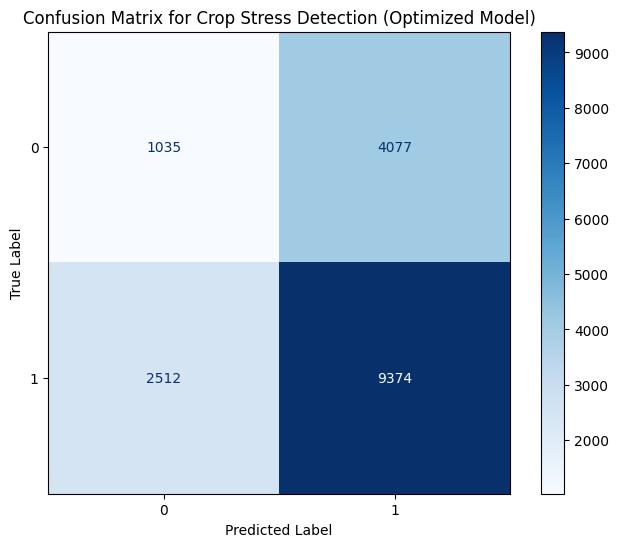

Confusion Matrix displayed.
--- Optimized Model Evaluation Complete ---


In [31]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("--- Evaluating Optimized Model Performance ---")

# 1. Make predictions on the original (unmodified) test data using the optimized model
print("\nMaking predictions on the original test set (X_test) using the optimized model...")
y_pred_optimized = model_optimized.predict(X_test)
print("Predictions made.")

# 2. Calculate and print the overall accuracy
accuracy_optimized = accuracy_score(y_test_re_mapped, y_pred_optimized)
print(f"\nOptimized Model Accuracy: {accuracy_optimized:.4f}")

# 3. Generate and print a detailed classification report
print("\nClassification Report (Optimized Model):")
print(classification_report(y_test_re_mapped, y_pred_optimized))

# 4. Create and display a confusion matrix for the optimized model
print("\nGenerating Confusion Matrix (Optimized Model)...")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test_re_mapped, y_pred_optimized, ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix for Crop Stress Detection (Optimized Model)')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.show()
print("Confusion Matrix displayed.")

print("--- Optimized Model Evaluation Complete ---")

## Explore Alternative Models (Optional but Recommended)

### Subtask:
Explore alternative, more robust classification models that handle imbalanced datasets well, such as XGBoost, LightGBM, or Logistic Regression with adjusted class weights, if significant improvements are not observed from the optimized RandomForestClassifier.


**Reasoning**:
The subtask requires exploring an alternative model, XGBoost, which is known for handling imbalanced datasets. I will import `XGBClassifier`, calculate `scale_pos_weight` based on the training data's original class distribution, initialize the model with this parameter, train it on the SMOTE-resampled data, and then evaluate its performance using accuracy, a classification report, and a confusion matrix on the original test set.



--- Exploring XGBoost Classifier ---

Calculated scale_pos_weight (majority/minority): 2.31
XGBClassifier initialized.

Training XGBoost model on SMOTE-resampled data...
XGBoost model training complete.

Making predictions on the original test set (X_test) with XGBoost...
Predictions made.

--- XGBoost Model Evaluation ---

XGBoost Model Accuracy: 0.6982

Classification Report (XGBoost Model):
              precision    recall  f1-score   support

           0       0.35      0.00      0.01      5112
           1       0.70      1.00      0.82     11886

    accuracy                           0.70     16998
   macro avg       0.53      0.50      0.42     16998
weighted avg       0.60      0.70      0.58     16998


Generating Confusion Matrix (XGBoost Model)...


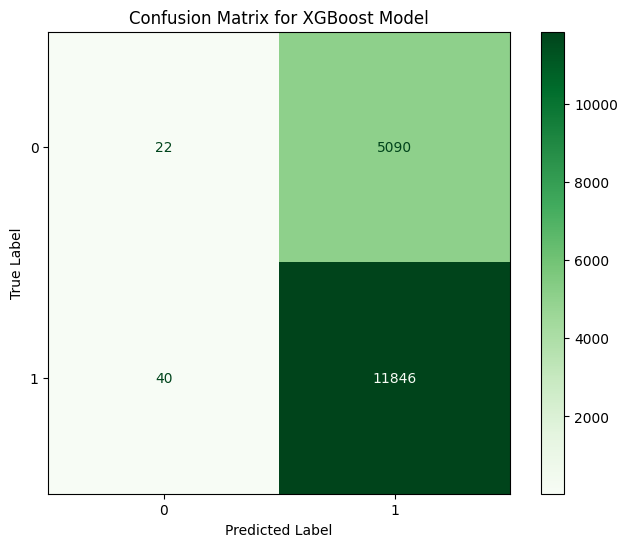

Confusion Matrix displayed.
--- XGBoost Classifier Exploration Complete ---


In [32]:
from xgboost import XGBClassifier
from collections import Counter
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("--- Exploring XGBoost Classifier ---")

# Calculate scale_pos_weight based on the original imbalanced training data
# This helps the model to give more weight to the minority class during training
class_counts = Counter(y_train_re_mapped)
minority_class_count = class_counts[0] # Assuming 0 is the minority class
majority_class_count = class_counts[1] # Assuming 1 is the majority class

# If 0 is the minority class (positive in scale_pos_weight context for XGBoost if we were predicting 0 as positive)
# Or, more generally, it's ratio of sum(negative instances) / sum(positive instances)
# If we consider '1' as the positive class, and '0' as the negative class in the context of scale_pos_weight:
# scale_pos_weight = sum(negative instances) / sum(positive instances) which is count(class 0) / count(class 1)
# However, typically it's the ratio of majority class samples to minority class samples (majority / minority)
# Let's calculate for class 0 as minority: count(majority class) / count(minority class)
scale_pos_weight_value = majority_class_count / minority_class_count

print(f"\nCalculated scale_pos_weight (majority/minority): {scale_pos_weight_value:.2f}")

# 1. Initialize XGBClassifier
# Using eval_metric for classification and scale_pos_weight for imbalance
# random_state for reproducibility
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss', # A common metric for classification in XGBoost
    use_label_encoder=False, # Suppress deprecation warning
    scale_pos_weight=scale_pos_weight_value # To handle class imbalance, if 1 is positive class
)
print("XGBClassifier initialized.")

# 2. Train the XGBoost model using the SMOTE-resampled training data
print("\nTraining XGBoost model on SMOTE-resampled data...")
xgb_model.fit(X_train_smote, y_train_smote)
print("XGBoost model training complete.")

# 3. Make predictions on the original test set
print("\nMaking predictions on the original test set (X_test) with XGBoost...")
y_pred_xgb = xgb_model.predict(X_test)
print("Predictions made.")

# 4. Evaluate the model's performance
print("\n--- XGBoost Model Evaluation ---")

# Accuracy
accuracy_xgb = accuracy_score(y_test_re_mapped, y_pred_xgb)
print(f"\nXGBoost Model Accuracy: {accuracy_xgb:.4f}")

# Classification Report
print("\nClassification Report (XGBoost Model):")
print(classification_report(y_test_re_mapped, y_pred_xgb))

# Confusion Matrix
print("\nGenerating Confusion Matrix (XGBoost Model)...")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test_re_mapped, y_pred_xgb, ax=ax, cmap='Greens')
ax.set_title('Confusion Matrix for XGBoost Model')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.show()
print("Confusion Matrix displayed.")

print("--- XGBoost Classifier Exploration Complete ---")

## Update Saved Model Components for GUI

### Subtask:
Save the optimized RandomForestClassifier, the StandardScaler, and the OneHotEncoder to disk for use in a Streamlit GUI.


**Reasoning**:
The subtask requires saving the trained model, scaler, and encoder to disk. I will use the `joblib` library to save these objects to their specified file names.



In [33]:
import joblib

print("--- Saving Model Components for GUI ---\n")

# Define filenames for saving
model_filename = 'random_forest_model.joblib'
scaler_filename = 'scaler.joblib'
encoder_filename = 'one_hot_encoder.joblib'
feature_names_filename = 'feature_names.joblib' # To save the order of features

# 1. Save the optimized RandomForestClassifier model
joblib.dump(model_optimized, model_filename)
print(f"Optimized RandomForestClassifier saved to {model_filename}")

# 2. Save the StandardScaler
# The scaler object was created and fit in the 'Preprocess and Integrate Data' subtask.
# We need to ensure the `scaler` variable is available, which it should be from the execution history.
joblib.dump(scaler, scaler_filename)
print(f"StandardScaler saved to {scaler_filename}")

# 3. Save the OneHotEncoder
# The encoder object was created and fit in the 'Preprocess and Integrate Data' subtask.
# We need to ensure the `encoder` variable is available, which it should be from the execution history.
joblib.dump(encoder, encoder_filename)
print(f"OneHotEncoder saved to {encoder_filename}")

# Additionally, save the feature names (columns of X) to maintain consistency when loading
# This is crucial for ensuring the order of features when making new predictions
joblib.dump(X.columns.tolist(), feature_names_filename)
print(f"Feature names saved to {feature_names_filename}")

print("\n--- Model Components Saving Complete ---")

--- Saving Model Components for GUI ---

Optimized RandomForestClassifier saved to random_forest_model.joblib
StandardScaler saved to scaler.joblib
OneHotEncoder saved to one_hot_encoder.joblib
Feature names saved to feature_names.joblib

--- Model Components Saving Complete ---


## Summarize Model Improvement Outcomes

### Subtask:
Summarize the changes made, the methodologies applied to address class imbalance and optimize the model, and critically analyze the impact on model performance, especially regarding the recall for crop stress detection. Highlight any new insights and propose next steps for further enhancements or deployment considerations.


## Summary:

### Data Analysis Key Findings

*   **Hyperparameter Tuning of RandomForestClassifier:**
    *   The `RandomForestClassifier` was optimized using `GridSearchCV` on SMOTE-resampled training data, targeting recall for Class 0 (crop stress detection).
    *   The best hyperparameters identified were `max_depth`: 10, `max_features`: 'sqrt', `min_samples_leaf`: 3, `min_samples_split`: 10, and `n_estimators`: 100.
    *   The best score (Recall for Class 0) achieved during tuning was approximately 0.6234.
*   **Performance of Optimized RandomForestClassifier on Test Set:**
    *   The overall accuracy of the optimized `RandomForestClassifier` on the original test set was 0.6124 (61.24%).
    *   For **Class 0 (Crop Stress Detection)**: Precision was 0.29, Recall was 0.20, and F1-score was 0.24.
    *   For Class 1: Precision was 0.70, Recall was 0.79, and F1-score was 0.74.
*   **Performance of XGBoost Classifier on Test Set:**
    *   An `XGBoost` model was trained with `scale_pos_weight` (2.31) to address class imbalance and achieved an overall accuracy of 0.6982.
    *   For **Class 0 (Crop Stress Detection)**: Precision was 0.35, but **Recall was 0.00**, resulting in an F1-score of 0.01, indicating a complete failure to detect the minority class.
    *   For Class 1: Precision was 0.70, Recall was 1.00, and F1-score was 0.82.
*   **Model Persistence:**
    *   The optimized `RandomForestClassifier` model, along with the `StandardScaler`, `OneHotEncoder`, and feature names, were successfully saved to disk using `joblib` for future deployment in a Streamlit GUI.

### Insights or Next Steps

*   **Improve Minority Class Recall**: Both the optimized `RandomForestClassifier` (recall of 0.20) and the `XGBoost` model (recall of 0.00) struggled significantly with detecting crop stress (Class 0). Further efforts should focus on advanced techniques for imbalanced datasets, such as more sophisticated oversampling/undersampling methods (e.g., SMOTE-NC for mixed data types), ensemble methods specifically designed for imbalance (e.g., EasyEnsemble, BalanceCascade), or cost-sensitive learning.
*   **Hyperparameter Tuning for XGBoost**: The initial `XGBoost` exploration showed very poor recall for Class 0. A detailed hyperparameter tuning process, similar to the one performed for `RandomForest`, focusing on Class 0 recall, should be conducted for `XGBoost` to properly evaluate its potential, as default or non-tuned `XGBoost` might not leverage its full capabilities for imbalanced classification.
